<a href="https://colab.research.google.com/github/ritashreemukherjee123/_PYTHON_Data__Analysis---/blob/main/SentimentAnalysisUsingVader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import nltk
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from nltk.corpus import stopwords

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,\
                            classification_report, confusion_matrix, ConfusionMatrixDisplay

https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [7]:
df = pd.read_csv("IMDB Dataset.csv")

df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
df.isnull().sum()

,0
review,0
sentiment,0


In [10]:
df.duplicated().sum()

np.int64(418)

In [11]:
df.drop_duplicates(inplace=True)

df.duplicated().sum()

np.int64(0)

In [12]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


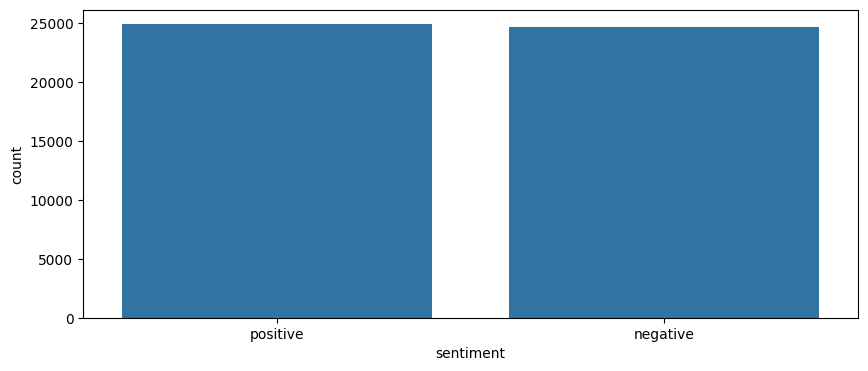

In [13]:
plt.figure(figsize=(10, 4))

sns.countplot(data=df, x="sentiment")

plt.show()

##### Checking word counts for each instance of tweets

In [14]:
df["word_count"] = df["review"].apply(lambda x: len(str(x).split(" ")))

df[["review", "word_count"]].head()

,review,word_count
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


In [15]:
df.sample(10)

,review,sentiment,word_count
18210,"I love horror films, but I think they work way...",positive,191
10841,"Imagine you're a high-school boy, in the back ...",negative,71
42508,I'm not sure why I picked for a borrow from mo...,positive,538
46171,(SPOILERS included) This film surely is the be...,positive,662
25570,Story of a good-for-nothing poet and a sidekic...,negative,65
9854,"Inept, boring, and incoherent supernatural ""th...",negative,164
18532,I can't express enough just how bad this film ...,negative,171
13021,"Blue ribbon banners, stars and stripes forever...",positive,623
31547,The fact that I watched this entire movie says...,negative,245
20770,"Sure I've seen bad movies in my life, but this...",negative,121


In [16]:
df.groupby("sentiment")["word_count"].mean()

,word_count
sentiment,
negative,229.586080
positive,233.079047


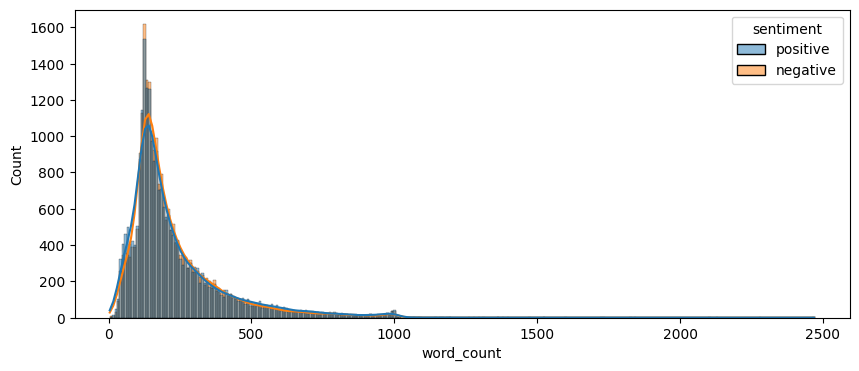

In [17]:
plt.figure(figsize=(10, 4))

sns.histplot(data=df, x="word_count", hue="sentiment", kde=True)

plt.show()

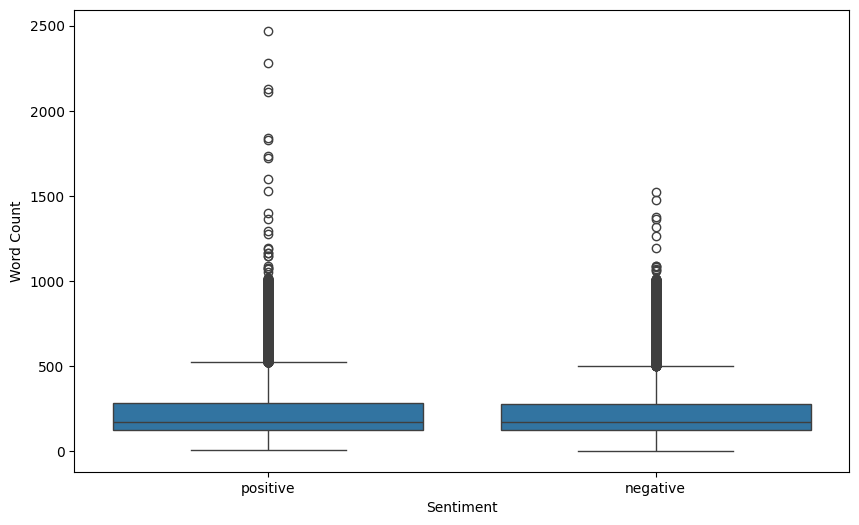

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="sentiment", y="word_count", data=df)

plt.xlabel('Sentiment')
plt.ylabel('Word Count')

plt.show()

In [19]:
def clean_text(input_text):

    text = str(input_text).lower()

    # Replace URLs with empty string
    text = re.sub(r"http\S+", "", text)

    # Replace emails with empty string
    text = re.sub("\S*@\S*\s?", "", text)

    # Replace punctuation with empty string
    text = re.sub("[%s]" % re.escape(string.punctuation), "", text)

    # Replace newline with empty string
    text = re.sub("\n", "", text)

    # Replace digits (even within words) with empty string
    text = re.sub("\w*\d\w*", "", text)

    return text

<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:18: SyntaxWarning: invalid escape sequence '\w'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:18: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1610/1014785702.py:9: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub("\S*@\S*\s?", "", text)
/tmp/ipykernel_1610/1014785702.py:18: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub("\w*\d\w*", "", text)


In [20]:
df["review"][1]

'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams\' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master\'s of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional \'dream\' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell\'s murals decorating every surface) are terribly well d

In [21]:
clean_text(df["review"][1])

'a wonderful little production br br the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece br br the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life br br the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done'

In [22]:
df["review"][10]

'Phil the Alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines.<br /><br />At first it was very odd and pretty funny but as the movie progressed I didn\'t find the jokes or oddness funny anymore.<br /><br />Its a low budget film (thats never a problem in itself), there were some pretty interesting characters, but eventually I just lost interest.<br /><br />I imagine this film would appeal to a stoner who is currently partaking.<br /><br />For something similar but better try "Brother from another planet"'

In [23]:
clean_text(df["review"][10])

'phil the alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlinesbr br at first it was very odd and pretty funny but as the movie progressed i didnt find the jokes or oddness funny anymorebr br its a low budget film thats never a problem in itself there were some pretty interesting characters but eventually i just lost interestbr br i imagine this film would appeal to a stoner who is currently partakingbr br for something similar but better try brother from another planet'

In [24]:
df["Cleaned Review"] = df["review"].apply(clean_text)

df.head(10)

,review,sentiment,word_count,Cleaned Review
0,One of the other reviewers has mentioned that ...,positive,307,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,162,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,positive,166,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,138,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter matteis love in the time of money is a ...
5,"Probably my all-time favorite movie, a story o...",positive,119,probably my alltime favorite movie a story of ...
6,I sure would like to see a resurrection of a u...,positive,150,i sure would like to see a resurrection of a u...
7,"This show was an amazing, fresh & innovative i...",negative,174,this show was an amazing fresh innovative ide...
8,Encouraged by the positive comments about this...,negative,130,encouraged by the positive comments about this...
9,If you like original gut wrenching laughter yo...,positive,33,if you like original gut wrenching laughter yo...


In [26]:
import nltk
nltk.download('stopwords')

stopword = set(stopwords.words('english'))

stopword

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [27]:
def remove_stopwords(text):
    text = ' '.join([word for word in text.split() if word not in stopword])

    return text

In [28]:
df['Cleaned Review'][25]

'the karen carpenter story shows a little more about singer karen carpenters complex life though it fails in giving accurate facts and detailsbr br cynthia gibb portrays karen was not a fine election she is a good actress  but plays a very naive and sort of dumb karen carpenter i think that the role needed a stronger character someone with a stronger personalitybr br louise fletcher role as agnes carpenter is terrific she does a great job as karens motherbr br it has great songs which could have been included in a soundtrack album unfortunately they werent though this movie was on the top of the ratings in usa and other several countries'

In [29]:
remove_stopwords(df['Cleaned Review'][25])

'karen carpenter story shows little singer karen carpenters complex life though fails giving accurate facts detailsbr br cynthia gibb portrays karen fine election good actress plays naive sort dumb karen carpenter think role needed stronger character someone stronger personalitybr br louise fletcher role agnes carpenter terrific great job karens motherbr br great songs could included soundtrack album unfortunately werent though movie top ratings usa several countries'

In [30]:
df['Cleaned Review'][100]

'this short film that inspired the soontobe full length feature  spatula madness  is a hilarious piece that contends against similar cartoons yielding multiple writers the short film stars edward the spatula who after being fired from his job joins in the fight against the evil spoons this premise allows for some funny content near the beginning but is barely present for the remainder of the feature this films  running time is absorbed by some oddball comedy and a small musical number unfortunately not much else lies below it the plot that is set up doesnt really have time to show but its surely follows it plot better than many highbudget hollywood films this film is worth watching at least a few times take it for what it is and dont expect a deep story'

In [31]:
remove_stopwords(df['Cleaned Review'][100])

'short film inspired soontobe full length feature spatula madness hilarious piece contends similar cartoons yielding multiple writers short film stars edward spatula fired job joins fight evil spoons premise allows funny content near beginning barely present remainder feature films running time absorbed oddball comedy small musical number unfortunately much else lies plot set doesnt really time show surely follows plot better many highbudget hollywood films film worth watching least times take dont expect deep story'

In [32]:
df["Cleaned Review"] = df["Cleaned Review"].apply(remove_stopwords)

df.sample(10)

,review,sentiment,word_count,Cleaned Review
10208,"John Holmes is so famous, he's infamous (as th...",positive,570,john holmes famous hes infamous three amigos w...
46354,Loved the movie. Loved the two families crossi...,positive,145,loved movie loved two families crossing paths ...
13375,Nothing can prepare you for another lousy bimb...,negative,154,nothing prepare another lousy bimbo outing tim...
7263,A lush fantasy world with quirky characters an...,positive,44,lush fantasy world quirky characters annoying ...
48199,I remember I saw this cartoon when I was 6 or ...,negative,161,remember saw cartoon grandfather picked video ...
41465,"From start to finish, this 1926 classic two re...",positive,202,start finish classic two reeler hal roach stud...
42168,I absolutely loved this movie. I am not even s...,positive,138,absolutely loved movie even sure particularly ...
9553,I own 2 home entertainment stores and I've see...,negative,164,home entertainment stores ive seen lot bad mov...
7065,Almost missed it. While visiting friends in Ph...,positive,93,almost missed visiting friends philadelphia so...
2935,"'Apocalypse Now Redux', Francis Ford Coppola's...",positive,575,apocalypse redux francis ford coppolas war opu...


In [33]:
positive_words = df[df['sentiment'] == "positive"]['Cleaned Review']

positive_word = ' '.join(positive_words)

wordcloud = WordCloud(width = 800,
                      height = 400,
                      background_color = "white").generate(positive_word)

wordcloud

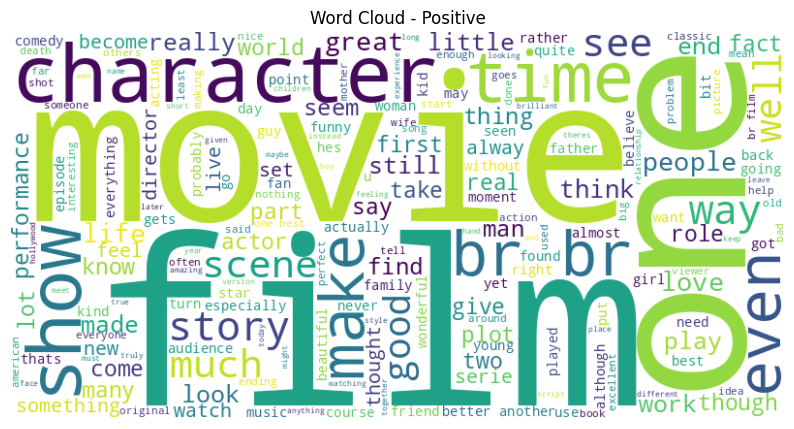

In [34]:
plt.figure(figsize = (10, 6))

plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive")

plt.show()

In [35]:
negative_words = df[df['sentiment'] == "negative"]['Cleaned Review']

negative_word = ' '.join(negative_words)

wordcloud = WordCloud(width = 800,
                      height = 400,
                      background_color = "white").generate(negative_word)

wordcloud

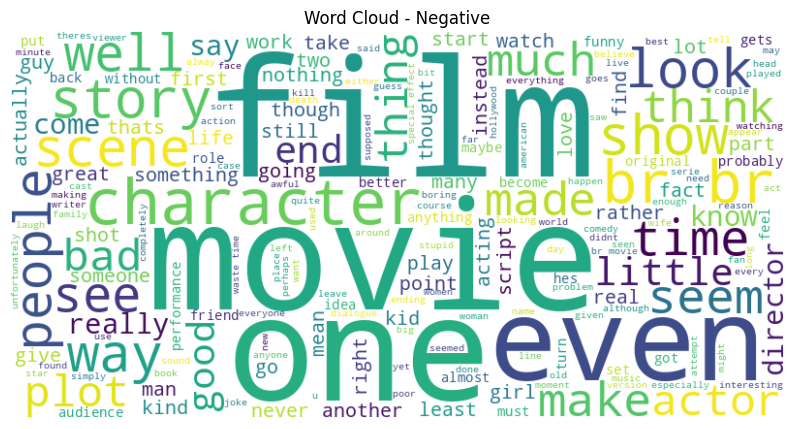

In [36]:
plt.figure(figsize = (10, 6))

plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative")

plt.show()

The vader_lexicon is a sentiment lexicon that is part of the Natural Language Toolkit (NLTK), a popular Python library for natural language processing (NLP). The vader_lexicon is not included in NLTK itself; rather, it is a lexicon used by the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis tool.

The vader_lexicon contains a collection of words and phrases, each associated with a sentiment score. The sentiment scores include positive, negative, and neutral values, and they indicate the degree of sentiment polarity associated with each word or phrase.

In [37]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [38]:
sia = SentimentIntensityAnalyzer()

sia

In [39]:
help(sia)

Help on SentimentIntensityAnalyzer in module nltk.sentiment.vader object:

class SentimentIntensityAnalyzer(builtins.object)
 |  SentimentIntensityAnalyzer(
 |      lexicon_file='sentiment/vader_lexicon.zip/vader_lexicon/vader_lexicon.txt'
 |  )
 |
 |  Give a sentiment intensity score to sentences.
 |
 |  Methods defined here:
 |
 |  __init__(
 |      self,
 |      lexicon_file='sentiment/vader_lexicon.zip/vader_lexicon/vader_lexicon.txt'
 |  )
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  make_lex_dict(self)
 |      Convert lexicon file to a dictionary
 |
 |  polarity_scores(self, text)
 |      Return a float for sentiment strength based on the input text.
 |      Positive values are positive valence, negative value are negative
 |      valence.
 |
 |      :note: Hashtags are not taken into consideration (e.g. #BAD is neutral). If you
 |          are interested in processing the text in the hashtags too, then we recommend
 |          preprocessing your 

##### Positive

In [40]:
text = "Rahul is a very amazing cricketer, his shots are a sight to behold"

sia.polarity_scores(text)

{'neg': 0.0, 'neu': 0.71, 'pos': 0.29, 'compound': 0.624}

###### Neutral

In [41]:
text = "The movie was an average one, I would not see it more than once"

sia.polarity_scores(text)

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

###### Negative

In [42]:
text = "The food delivered was really very bad, definitely would not recommend"

sia.polarity_scores(text)

{'neg': 0.355, 'neu': 0.459, 'pos': 0.186, 'compound': -0.4477}

##### Function to calculate polarity scores is defined

In [43]:
pol_scorer = lambda x: sia.polarity_scores(x)

pol_scorer

<function __main__.<lambda>(x)>

In [44]:
df["polarity_score"] = df["Cleaned Review"].apply(pol_scorer)

df[['Cleaned Review', 'sentiment', 'polarity_score']].sample(10)

,Cleaned Review,sentiment,polarity_score
49194,ben rupert grint deeply unhappy adolescent son...,negative,"{'neg': 0.218, 'neu': 0.588, 'pos': 0.194, 'co..."
31886,figure empress elizabeth austria indeed mostly...,negative,"{'neg': 0.143, 'neu': 0.637, 'pos': 0.22, 'com..."
2746,father son communicate little fact speak diffe...,positive,"{'neg': 0.033, 'neu': 0.707, 'pos': 0.26, 'com..."
16675,watched part one two days ago today saw part t...,positive,"{'neg': 0.215, 'neu': 0.659, 'pos': 0.126, 'co..."
11508,many socalled antiwarantigovt policy films aro...,negative,"{'neg': 0.275, 'neu': 0.624, 'pos': 0.101, 'co..."
1171,shirley temple short subjectbr br get mighty r...,positive,"{'neg': 0.097, 'neu': 0.66, 'pos': 0.243, 'com..."
2201,movie title tartbr br date review br year movi...,negative,"{'neg': 0.178, 'neu': 0.584, 'pos': 0.238, 'co..."
27257,brainless film good looking brainless couple d...,negative,"{'neg': 0.102, 'neu': 0.686, 'pos': 0.211, 'co..."
31470,cant recommend film date movie gary oldmans se...,negative,"{'neg': 0.174, 'neu': 0.826, 'pos': 0.0, 'comp..."
12955,first complete dramatic works william shakespe...,negative,"{'neg': 0.113, 'neu': 0.669, 'pos': 0.218, 'co..."


In [45]:
df["negative"] = df["polarity_score"].apply(lambda txt: txt["neg"])

df['positive'] = df["polarity_score"].apply(lambda txt: txt['pos'])

df['compound'] = df["polarity_score"].apply(lambda txt: txt['compound'])

df

,review,sentiment,word_count,Cleaned Review,polarity_score,negative,positive,compound
0,One of the other reviewers has mentioned that ...,positive,307,one reviewers mentioned watching oz episode yo...,"{'neg': 0.295, 'neu': 0.605, 'pos': 0.1, 'comp...",0.295,0.100,-0.9934
1,A wonderful little production. <br /><br />The...,positive,162,wonderful little production br br filming tech...,"{'neg': 0.075, 'neu': 0.657, 'pos': 0.268, 'co...",0.075,0.268,0.9582
2,I thought this was a wonderful way to spend ti...,positive,166,thought wonderful way spend time hot summer we...,"{'neg': 0.148, 'neu': 0.549, 'pos': 0.302, 'co...",0.148,0.302,0.9520
3,Basically there's a family where a little boy ...,negative,138,basically theres family little boy jake thinks...,"{'neg': 0.213, 'neu': 0.658, 'pos': 0.129, 'co...",0.213,0.129,-0.8858
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter matteis love time money visually stunni...,"{'neg': 0.03, 'neu': 0.722, 'pos': 0.249, 'com...",0.030,0.249,0.9871
...,...,...,...,...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,194,thought movie right good job wasnt creative or...,"{'neg': 0.08, 'neu': 0.616, 'pos': 0.304, 'com...",0.080,0.304,0.9762
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,bad plot bad dialogue bad acting idiotic direc...,"{'neg': 0.343, 'neu': 0.459, 'pos': 0.198, 'co...",0.343,0.198,-0.9320
49997,I am a Catholic taught in parochial elementary...,negative,230,catholic taught parochial elementary schools n...,"{'neg': 0.236, 'neu': 0.587, 'pos': 0.177, 'co...",0.236,0.177,-0.9074
49998,I'm going to have to disagree with the previou...,negative,212,im going disagree previous comment side maltin...,"{'neg': 0.152, 'neu': 0.712, 'pos': 0.135, 'co...",0.152,0.135,-0.5267


In [46]:
def polarity_score(compound):
    if compound >= 0.05:
        return "positive"
    elif compound < 0.05:
        return "negative"

In [47]:
df['predicted_sentiment'] = df['compound'].apply(lambda val: polarity_score(val))

df.sample(10)

,review,sentiment,word_count,Cleaned Review,polarity_score,negative,positive,compound,predicted_sentiment
10766,'The Cell' is a journey into the mind of a ser...,positive,504,cell journey mind serial killer mean literally...,"{'neg': 0.183, 'neu': 0.653, 'pos': 0.164, 'co...",0.183,0.164,-0.9104,negative
24905,"Rock Star is a ""nice"" movie. Everyone is nice....",positive,128,rock star nice movie everyone nice even guys a...,"{'neg': 0.039, 'neu': 0.638, 'pos': 0.323, 'co...",0.039,0.323,0.9759,positive
32123,"Someone told me that Pink Flamingos was, in a ...",negative,128,someone told pink flamingos word insane im dou...,"{'neg': 0.165, 'neu': 0.641, 'pos': 0.194, 'co...",0.165,0.194,0.3400,positive
36949,This was awful. Andie Macdowell is a terrible ...,negative,191,awful andie macdowell terrible actress wooden ...,"{'neg': 0.17, 'neu': 0.668, 'pos': 0.162, 'com...",0.170,0.162,-0.2908,negative
6274,If you go see this movie you'll be holding a g...,negative,125,go see movie youll holding grudge movie theatr...,"{'neg': 0.219, 'neu': 0.672, 'pos': 0.109, 'co...",0.219,0.109,-0.8741,negative
6390,Above-average film and acting partly spoiled b...,positive,72,aboveaverage film acting partly spoiled comple...,"{'neg': 0.136, 'neu': 0.813, 'pos': 0.051, 'co...",0.136,0.051,-0.6369,negative
33829,I just rented Blackwater Valley Exorcism becau...,negative,259,rented blackwater valley exorcism cover pictur...,"{'neg': 0.179, 'neu': 0.672, 'pos': 0.15, 'com...",0.179,0.150,-0.5566,negative
28594,Myself and my groovadelic 20-something pals ju...,positive,169,groovadelic pals cant get enough awesome parke...,"{'neg': 0.083, 'neu': 0.543, 'pos': 0.374, 'co...",0.083,0.374,0.9888,positive
29026,Lavish production values and solid performance...,positive,122,lavish production values solid performances st...,"{'neg': 0.134, 'neu': 0.545, 'pos': 0.32, 'com...",0.134,0.320,0.9435,positive
39031,Talk about rubbish! I can't think of one good ...,negative,300,talk rubbish cant think one good thing movie s...,"{'neg': 0.267, 'neu': 0.599, 'pos': 0.135, 'co...",0.267,0.135,-0.9831,negative


In [48]:
df['predicted_sentiment'].value_counts()

,count
predicted_sentiment,
positive,33771
negative,15811


In [49]:
accuracy = accuracy_score(df["sentiment"], df["predicted_sentiment"])

f1 = f1_score(df["sentiment"], df["predicted_sentiment"], average = None)

precision = precision_score(df["sentiment"], df["predicted_sentiment"], average = None)

recall = recall_score(df["sentiment"], df["predicted_sentiment"], average = None)

In [50]:
class_names = ["negative", "positive"]

print(f"Accuracy: {accuracy:.2f}")

for class_label, prec, rec, f1 in zip(class_names, precision, recall, f1):
    print(f"Class {class_label}:")
    print(f"   Precision: {prec:.2f}")
    print(f"   Recall: {rec:.2f}")
    print(f"   F1 score: {f1:.2f}")

Accuracy: 0.68
Class negative:
   Precision: 0.78
   Recall: 0.50
   F1 score: 0.61
Class positive:
   Precision: 0.63
   Recall: 0.86
   F1 score: 0.73


In [51]:
report = classification_report(df["sentiment"], df["predicted_sentiment"])

print(report)

              precision    recall  f1-score   support

    negative       0.78      0.50      0.61     24698
    positive       0.63      0.86      0.73     24884

    accuracy                           0.68     49582
   macro avg       0.70      0.68      0.67     49582
weighted avg       0.70      0.68      0.67     49582



In [52]:
pd.crosstab(df["sentiment"], df["predicted_sentiment"])

predicted_sentiment,negative,positive
sentiment,,
negative,12280,12418
positive,3531,21353


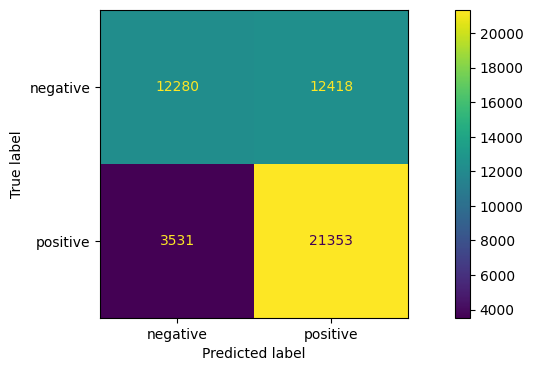

In [53]:
cm = confusion_matrix(df["sentiment"], df["predicted_sentiment"])
cmp = ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"])

fig, ax = plt.subplots(figsize=(12, 4))

cmp.plot(ax=ax)

In [54]:
df = df.drop(columns = ['negative', 'positive', 'compound',
                        'polarity_score', 'predicted_sentiment'])

df

,review,sentiment,word_count,Cleaned Review
0,One of the other reviewers has mentioned that ...,positive,307,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,positive,162,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,166,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,138,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230,petter matteis love time money visually stunni...
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,194,thought movie right good job wasnt creative or...
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,112,bad plot bad dialogue bad acting idiotic direc...
49997,I am a Catholic taught in parochial elementary...,negative,230,catholic taught parochial elementary schools n...
49998,I'm going to have to disagree with the previou...,negative,212,im going disagree previous comment side maltin...
